In [64]:
import pandas
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score
from sklearn.impute import SimpleImputer
from matplotlib.colors import LogNorm
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline 
from imblearn.combine import SMOTEENN
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_curve, auc, precision_score, recall_score, f1_score, precision_recall_fscore_support, ConfusionMatrixDisplay

In [65]:
BLACK = '\033[30m'
RED = '\033[31m'
GREEN = '\033[32m'
YELLOW = '\033[33m' # orange on some systems
BLUE = '\033[34m'
MAGENTA = '\033[35m'
CYAN = '\033[36m'
LIGHT_GRAY = '\033[37m'
DARK_GRAY = '\033[90m'
BRIGHT_RED = '\033[91m'
BRIGHT_GREEN = '\033[92m'
BRIGHT_YELLOW = '\033[93m'
BRIGHT_BLUE = '\033[94m'
BRIGHT_MAGENTA = '\033[95m'
BRIGHT_CYAN = '\033[96m'
RESET = '\033[0m' # called to return to standard terminal text color

def colored_text(color, txt):
    return color + str(txt) + RESET

In [66]:
datasets_path = "data"
years = [2019,2020, 2021, 2022, 2023, 2024]

df_caract = []

for year in years:
    df_caract_year = pandas.read_csv(os.path.join(datasets_path, str(year), f"caract-{year}.csv"), encoding="utf-8", sep = ";")
    df_caract.append(df_caract_year)

df_caract = pandas.concat(df_caract)
df_caract.head()

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long
0,201900000001,30,11,2019,01:30,4,93,93053,1,1,1,2,AUTOROUTE A3,"48,8962100","2,4701200"
1,201900000002,30,11,2019,02:50,3,93,93066,1,1,1,6,AUTOROUTE A1,"48,9307000","2,3688000"
2,201900000003,28,11,2019,15:15,1,92,92036,1,1,1,4,AUTOROUTE A86,"48,9358718","2,3191744"
3,201900000004,30,11,2019,20:20,5,94,94069,1,1,1,4,A4,"48,8173295","2,4281502"
4,201900000005,30,11,2019,04:00,3,94,94028,1,1,1,2,A86 INT,"48,7763620","2,4332540"


In [67]:
df_caract.columns

Index(['Num_Acc', 'jour', 'mois', 'an', 'hrmn', 'lum', 'dep', 'com', 'agg',
       'int', 'atm', 'col', 'adr', 'lat', 'long'],
      dtype='str')

In [68]:
df_caract.isna().sum()

Num_Acc       0
jour          0
mois          0
an            0
hrmn          0
lum           0
dep           0
com           0
agg           0
int           0
atm           0
col           0
adr        6289
lat           0
long          0
dtype: int64

In [69]:
# Drop ["adr","dep","com"] as we will work in our analysis with latitude and logitude and they contain this info already
df_caract.drop(columns=["adr","dep","com"],inplace=True)

In [70]:
df_caract.info()

<class 'pandas.DataFrame'>
Index: 327628 entries, 0 to 54401
Data columns (total 12 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   Num_Acc  327628 non-null  int64
 1   jour     327628 non-null  int64
 2   mois     327628 non-null  int64
 3   an       327628 non-null  int64
 4   hrmn     327628 non-null  str  
 5   lum      327628 non-null  int64
 6   agg      327628 non-null  int64
 7   int      327628 non-null  int64
 8   atm      327628 non-null  int64
 9   col      327628 non-null  int64
 10  lat      327628 non-null  str  
 11  long     327628 non-null  str  
dtypes: int64(9), str(3)
memory usage: 32.5 MB


In [71]:
df_caract["lat"] = pandas.to_numeric(
    df_caract["lat"].str.replace(",", "."),
    errors="coerce"
)

df_caract["long"] = pandas.to_numeric(
    df_caract["long"].str.replace(",", "."),
    errors="coerce"
)

In [72]:
df_caract = df_caract.replace(-1, pandas.NA)
df_caract.isna().sum()

Num_Acc       0
jour          0
mois          0
an            0
hrmn          0
lum           9
agg           0
int          14
atm          26
col        1619
lat           0
long          1
dtype: int64

In [73]:
cat_small_na = df_caract.columns[(df_caract.isna().sum() < 5000) & (df_caract.isna().sum() > 0)]
print(cat_small_na)
imputer = SimpleImputer(strategy="most_frequent")


df_caract[cat_small_na] = df_caract[cat_small_na].replace({pandas.NA: np.nan})
df_caract[cat_small_na] = imputer.fit_transform(df_caract[cat_small_na])
df_caract.isna().sum()

Index(['lum', 'int', 'atm', 'col', 'long'], dtype='str')


Num_Acc    0
jour       0
mois       0
an         0
hrmn       0
lum        0
agg        0
int        0
atm        0
col        0
lat        0
long       0
dtype: int64

In [74]:
column_names_to_int = ["jour", "mois", "lum", "agg", "int", "atm", "col"]

df_caract[column_names_to_int] = df_caract[column_names_to_int].apply(
    lambda col: pandas.to_numeric(
        col.astype(str).str.extract(r'(-?\d+)')[0],
        errors="coerce"
    )
)

In [75]:
df_caract[["lat", "long"]] = df_caract[["lat", "long"]].astype("float64")

In [76]:
df_caract["lat"].describe()

count    327628.000000
mean         44.343658
std          12.244762
min         -61.425660
25%          44.736676
50%          47.825103
75%          48.860313
max          63.568066
Name: lat, dtype: float64

In [77]:
df_caract["long"].describe()

count    327628.000000
mean          2.171736
std          19.084446
min        -178.158090
25%           1.283565
50%           2.391478
75%           4.795682
max         174.023438
Name: long, dtype: float64

Now we are taking into consideration only accidents that occurred in France

In [78]:
invalid_lat = df_caract[
    (df_caract["lat"] < 41) | (df_caract["lat"] > 51) 
]

len(invalid_lat) / len(df_caract)

0.05513570268719401

In [79]:
invalid_long = df_caract[
    (df_caract["long"] < -5) | (df_caract["long"] > 10)
]

len(invalid_long) / len(df_caract)

0.05454661994701308

In [80]:
df_caract = df_caract[
    (df_caract["lat"].between(41, 51)) &
    (df_caract["long"].between(-5, 10))
]

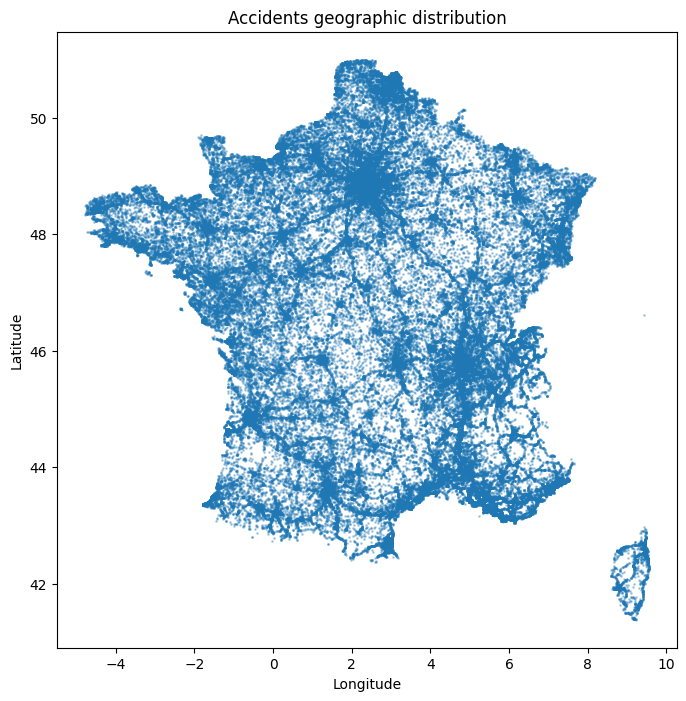

In [81]:
plt.figure(figsize=(8, 8))
plt.scatter(df_caract["long"], df_caract["lat"], s=1, alpha=0.3)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Accidents geographic distribution")
plt.show()

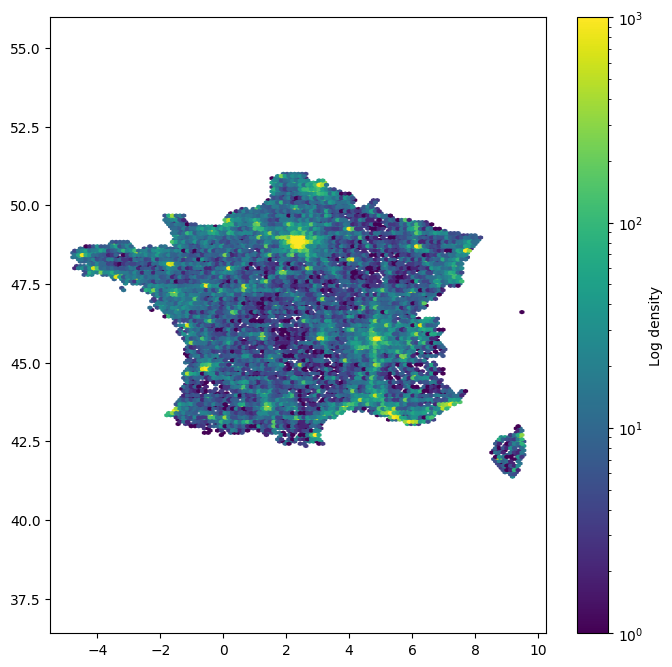

In [82]:
plt.figure(figsize=(8, 8))

hb = plt.hexbin(
    df_caract["long"],
    df_caract["lat"],
    gridsize=120,
    cmap="viridis",
    norm=LogNorm(vmin=1, vmax=1000)
)

plt.colorbar(hb, label="Log density")
plt.axis("equal")
plt.show()

In [83]:
# We need to load usagers, because it conatains our target column
df_usagers = pandas.read_csv("df_usagers_clean.csv")

df_caract_with_target = df_usagers[['Num_Acc', 'grav_bin']].merge(
    df_caract,
    on='Num_Acc',
    how='left'
)

target = "grav_bin"

In [84]:
df_caract_with_target.isna().sum()

Num_Acc         0
grav_bin        0
jour        42192
mois        42192
an          42192
hrmn        42192
lum         42192
agg         42192
int         42192
atm         42192
col         42192
lat         42192
long        42192
dtype: int64

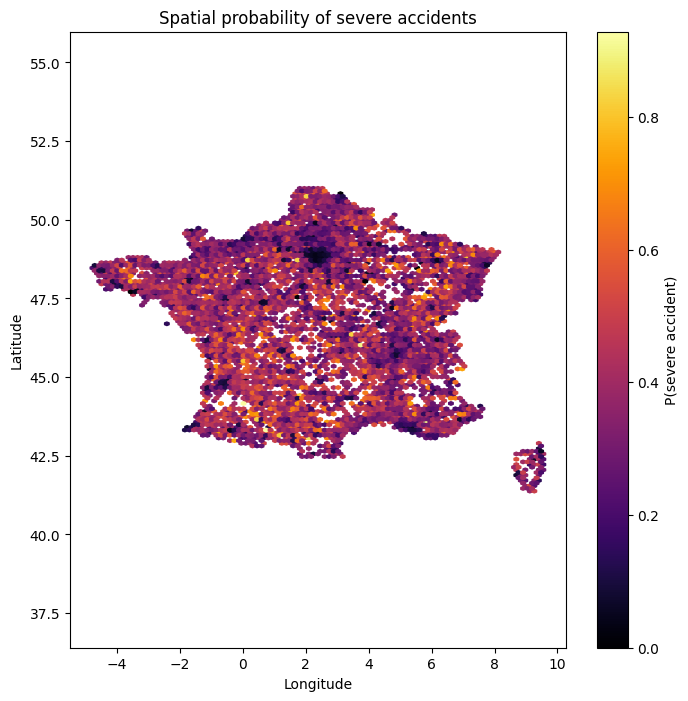

In [85]:
plt.figure(figsize=(8, 8))

hb = plt.hexbin(
    df_caract_with_target["long"],
    df_caract_with_target["lat"],
    C=df_caract_with_target["grav_bin"],
    reduce_C_function=np.mean, # probability of severe
    gridsize=100,
    cmap="inferno",
    mincnt=10 # ignore low-sample cells
)

plt.colorbar(hb, label="P(severe accident)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial probability of severe accidents")

plt.axis("equal")
plt.show()

Encodage temporel :

In [86]:
df_caract['mois'].describe()

count    309533.000000
mean          6.709769
std           3.357667
min           1.000000
25%           4.000000
50%           7.000000
75%          10.000000
max          12.000000
Name: mois, dtype: float64

In [87]:
df_caract['jour'].describe()

count    309533.000000
mean         15.632488
std           8.731284
min           1.000000
25%           8.000000
50%          16.000000
75%          23.000000
max          31.000000
Name: jour, dtype: float64

In [88]:
df_caract["date"] = pandas.to_datetime(
    dict(year=df_caract["an"],
    month=df_caract["mois"],
    day=df_caract["jour"]),
    errors="coerce"
)

In [89]:
df_caract["day_of_year"] = df_caract["date"].dt.dayofyear
df_caract["weekday"] = df_caract["date"].dt.weekday
df_caract["month"] = df_caract["date"].dt.month
df_caract["year"] = df_caract["date"].dt.year

Cycle annuel (jour dans l'année 365)

In [90]:
df_caract["day_sin"] = np.sin(2 * np.pi * df_caract["day_of_year"] / 365)
df_caract["day_cos"] = np.cos(2 * np.pi * df_caract["day_of_year"] / 365)

Cycle mensuel (12 mois)

In [91]:
df_caract["month_sin"] = np.sin(2 * np.pi * df_caract["month"] / 12)
df_caract["month_cos"] = np.cos(2 * np.pi * df_caract["month"] / 12)

Cycle hebdomadaire (7 jours)

In [92]:
df_caract["weekday_sin"] = np.sin(2 * np.pi * df_caract["weekday"] / 7)
df_caract["weekday_cos"] = np.cos(2 * np.pi * df_caract["weekday"] / 7)

Cycle horaire  (24 heures)

In [93]:
df_caract["hrmn"] = df_caract["hrmn"].astype(str).str.strip()
df_caract["hour"] = df_caract["hrmn"].str[:2].astype(int)

In [94]:
df_caract["hour_sin"] = np.sin(2 * np.pi * df_caract["hour"] / 24)
df_caract["hour_cos"] = np.cos(2 * np.pi * df_caract["hour"] / 24)

In [95]:
df_caract["is_weekend"] = df_caract["weekday"].isin([5, 6]).astype(int)

In [96]:
df_caract.drop(columns=["date", "day_of_year", "weekday","hour"
                        ,"month", "year","hrmn","an","jour","mois"], inplace=True)

In [97]:
df_caract.columns

Index(['Num_Acc', 'lum', 'agg', 'int', 'atm', 'col', 'lat', 'long', 'day_sin',
       'day_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos',
       'hour_sin', 'hour_cos', 'is_weekend'],
      dtype='str')

In [98]:
categorical_features = [
 'lum',
 'agg',
 'int',
 'atm',
 'col'
]
binary_features = ["is_weekend"]     
numerical_features = ['lat', 'long', 'day_sin',
       'day_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos',
       'hour_sin', 'hour_cos'] # binary numerical features is_weekend

features = categorical_features + binary_features + numerical_features

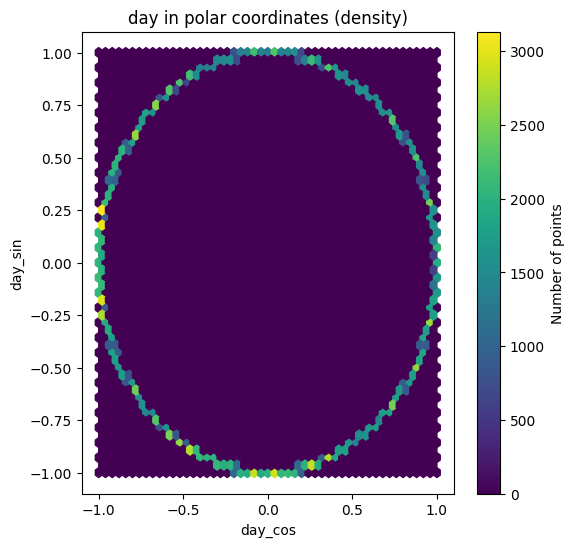

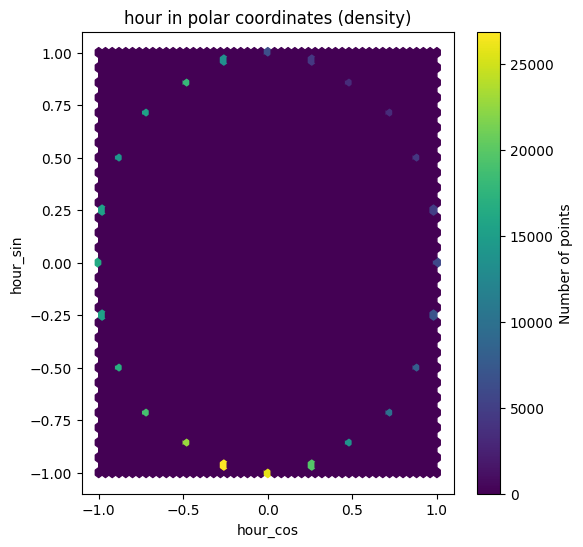

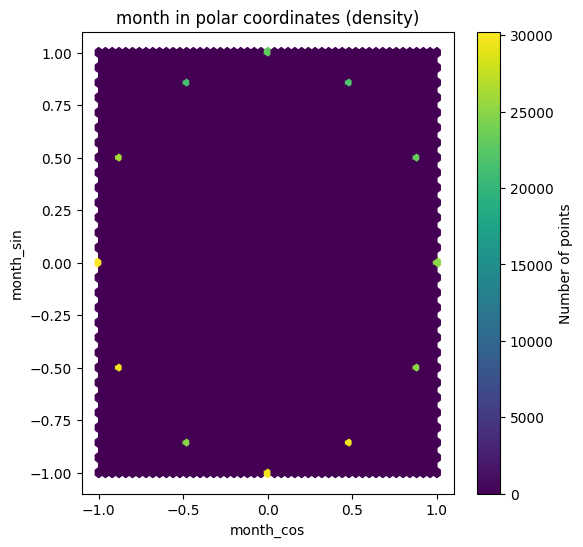

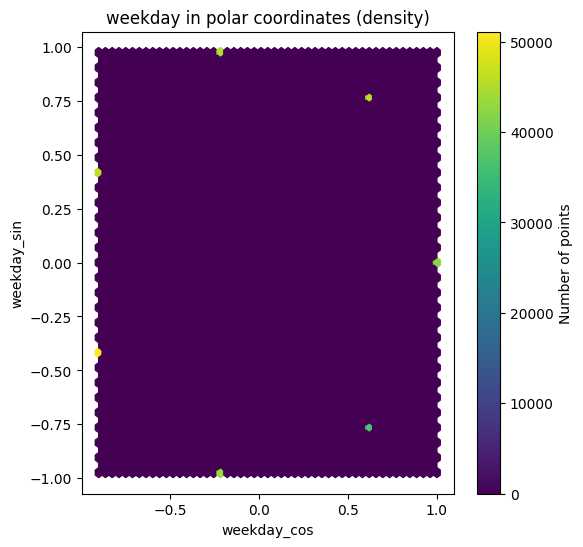

In [99]:
pairs = [('day_cos', 'day_sin'), ('hour_cos', 'hour_sin'), ('month_cos', 'month_sin'), ('weekday_cos', 'weekday_sin')]

for x, y in pairs:
    plt.figure(figsize=(6,6))
    plt.hexbin(df_caract[x], df_caract[y], gridsize=50, cmap='viridis')
    plt.colorbar(label='Number of points')
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x.split('_')[0]} in polar coordinates (density)")
    plt.show()

In [100]:
df_usagers = pandas.read_csv("df_usagers_clean.csv")
df_caract_with_target = df_usagers[['Num_Acc', 'grav_bin']].merge(
    df_caract,      
    on='Num_Acc',
    how='left'
)

In [101]:
df_caract_with_target.isna().sum()

Num_Acc            0
grav_bin           0
lum            42192
agg            42192
int            42192
atm            42192
col            42192
lat            42192
long           42192
day_sin        42192
day_cos        42192
month_sin      42192
month_cos      42192
weekday_sin    42192
weekday_cos    42192
hour_sin       42192
hour_cos       42192
is_weekend     42192
dtype: int64

In [102]:
df_caract_with_target = df_caract_with_target.dropna()

In [103]:
df_caract_analyse = df_caract_with_target.copy() 

In [104]:
df_caract_analyse['day_of_year'] = np.arctan2(df_caract_analyse['day_sin'], df_caract_analyse['day_cos'])
df_caract_analyse['day_of_year'] = (df_caract_analyse['day_of_year'] % (2*np.pi)) * 365 / (2*np.pi)

df_caract_analyse['hour'] = np.arctan2(df_caract_analyse['hour_sin'], df_caract_analyse['hour_cos'])
df_caract_analyse['hour'] = (df_caract_analyse['hour'] % (2*np.pi)) * 24 / (2*np.pi)

df_caract_analyse['month'] = np.arctan2(df_caract_analyse['month_sin'], df_caract_analyse['month_cos'])
df_caract_analyse['month'] = (df_caract_analyse['month'] % (2*np.pi)) * 12 / (2*np.pi)

df_caract_analyse['weekday'] = np.arctan2(df_caract_analyse['weekday_sin'], df_caract_analyse['weekday_cos'])
df_caract_analyse['weekday'] = (df_caract_analyse['weekday'] % (2*np.pi)) * 7 / (2*np.pi)     


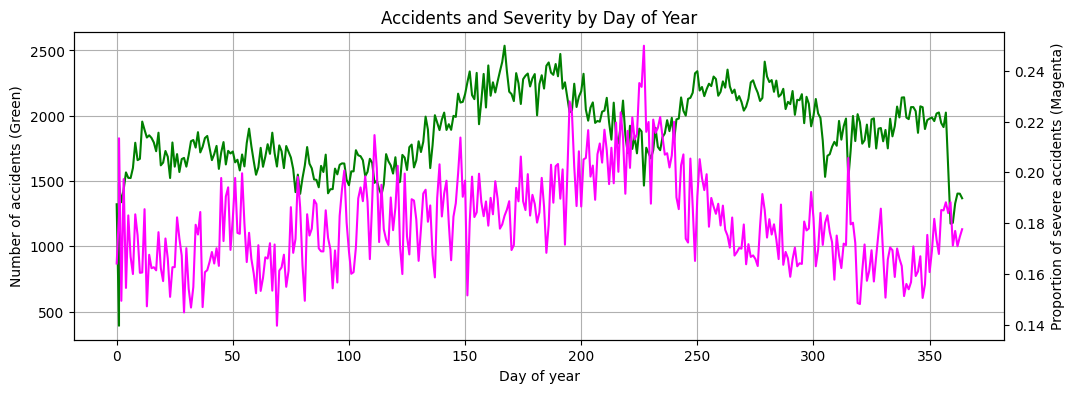

In [105]:
daily_counts = df_caract_analyse.groupby('day_of_year')['grav_bin'].count()
daily_severe = df_caract_analyse.groupby('day_of_year')['grav_bin'].mean()

fig, ax1 = plt.subplots(figsize=(12,4))

# First axis: counts
ax1.plot(daily_counts.index, daily_counts.values, color = "GREEN")
ax1.set_xlabel("Day of year")
ax1.set_ylabel("Number of accidents (Green)")
ax1.grid(True)

# Second axis: severity
ax2 = ax1.twinx()
ax2.plot(daily_severe.index, daily_severe.values, color = "MAGENTA")
ax2.set_ylabel("Proportion of severe accidents (Magenta)")

plt.title("Accidents and Severity by Day of Year")
plt.show()

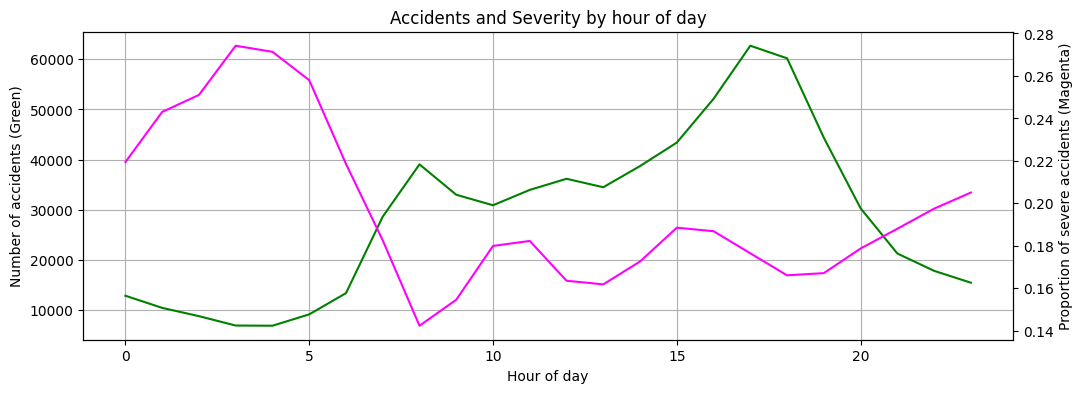

In [106]:
hourly_counts = df_caract_analyse.groupby('hour')['grav_bin'].count()
hourly_severe = df_caract_analyse.groupby('hour')['grav_bin'].mean()
fig, ax1 = plt.subplots(figsize=(12,4))

# First axis: counts
ax1.plot(hourly_counts.index, hourly_counts.values, color = "GREEN")
ax1.set_xlabel("Hour of day")
ax1.set_ylabel("Number of accidents (Green)")
ax1.grid(True)

# Second axis: severity
ax2 = ax1.twinx()
ax2.plot(hourly_severe.index, hourly_severe.values, color = "MAGENTA")
ax2.set_ylabel("Proportion of severe accidents (Magenta)")

plt.title("Accidents and Severity by hour of day")
plt.show()

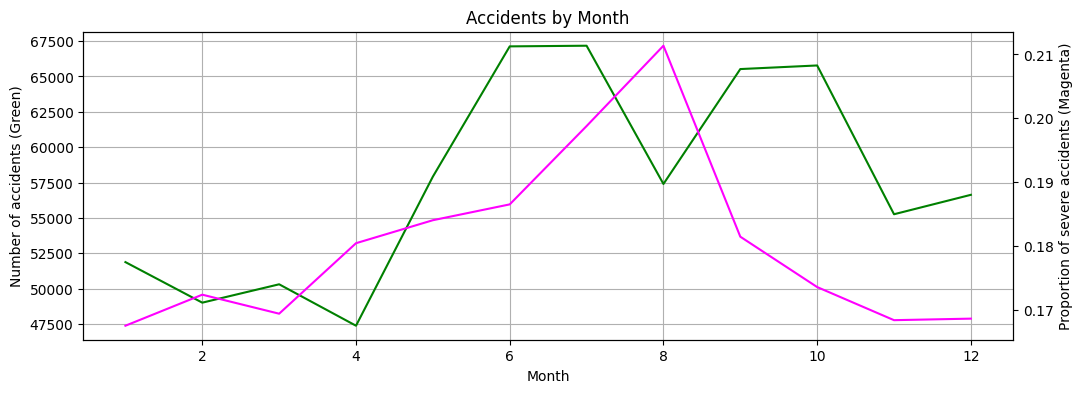

In [107]:
monthly_counts = df_caract_analyse.groupby('month')['grav_bin'].count()
monthly_severe = df_caract_analyse.groupby('month')['grav_bin'].mean()
fig, ax1 = plt.subplots(figsize=(12,4))

# First axis: counts
ax1.plot(monthly_counts.index, monthly_counts.values, color = "GREEN")
ax1.set_xlabel("Month")
ax1.set_ylabel("Number of accidents (Green)")
ax1.grid(True)

# Second axis: severity
ax2 = ax1.twinx()
ax2.plot(monthly_severe.index, monthly_severe.values, color = "MAGENTA")
ax2.set_ylabel("Proportion of severe accidents (Magenta)")

plt.title("Accidents by Month")
plt.show()

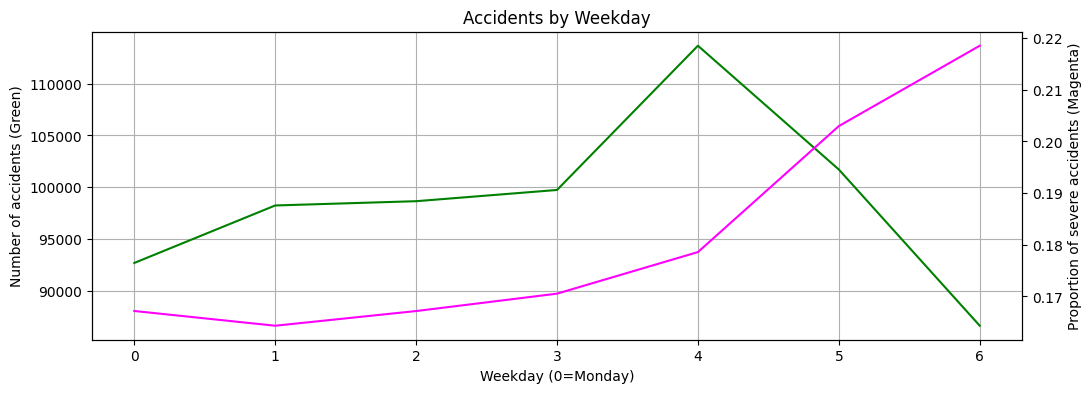

In [108]:
weekly_counts = df_caract_analyse.groupby('weekday')['grav_bin'].count()
weekly_severe = df_caract_analyse.groupby('weekday')['grav_bin'].mean()
fig, ax1 = plt.subplots(figsize=(12,4))

# First axis: counts
ax1.plot(weekly_counts.index, weekly_counts.values, color = "GREEN")
ax1.set_xlabel("Weekday (0=Monday)")
ax1.set_ylabel("Number of accidents (Green)")
ax1.grid(True)

# Second axis: severity
ax2 = ax1.twinx()
ax2.plot(weekly_severe.index, weekly_severe.values, color = "MAGENTA")
ax2.set_ylabel("Proportion of severe accidents (Magenta)")

plt.title("Accidents by Weekday")
plt.show()

In [109]:
mapping = {
    1: "Daylight",
    2: "Twilight or dawn",
    3: "Night without public lighting",
    4: "Night with public lighting not lit",
    5: "Night with public lighting lit"
}
df_caract_analyse["lum"] = df_caract_analyse["lum"].replace(mapping)

mapping = {
    1: "Outside built-up area",
    2: "Inside built-up area"
}
df_caract_analyse["agg"] = df_caract_analyse["agg"].replace(mapping)

mapping = {
    1: "No intersection",
    2: "X intersection",
    3: "T intersection",
    4: "Y intersection",
    5: "Intersection with more than 4 branches",
    6: "Roundabout",
    7: "Square",
    8: "Level crossing",
    9: "Other intersection"
}
df_caract_analyse["int"] = df_caract_analyse["int"].replace(mapping)

mapping = {
    1: "Normal",
    2: "Light rain",
    3: "Heavy rain",
    4: "Snow / hail",
    5: "Fog / smoke",
    6: "Strong wind / storm",
    7: "Dazzling weather (glare)",
    8: "Overcast",
    9: "Other"
}
df_caract_analyse["atm"] = df_caract_analyse["atm"].replace(mapping)

mapping = {
    1: "Two vehicles – head-on",
    2: "Two vehicles – rear-end",
    3: "Two vehicles – side collision",
    4: "Three or more vehicles – chain collision",
    5: "Three or more vehicles – multiple collisions",
    6: "Other collision",
    7: "No collision"
}
df_caract_analyse["col"] = df_caract_analyse["col"].replace(mapping)

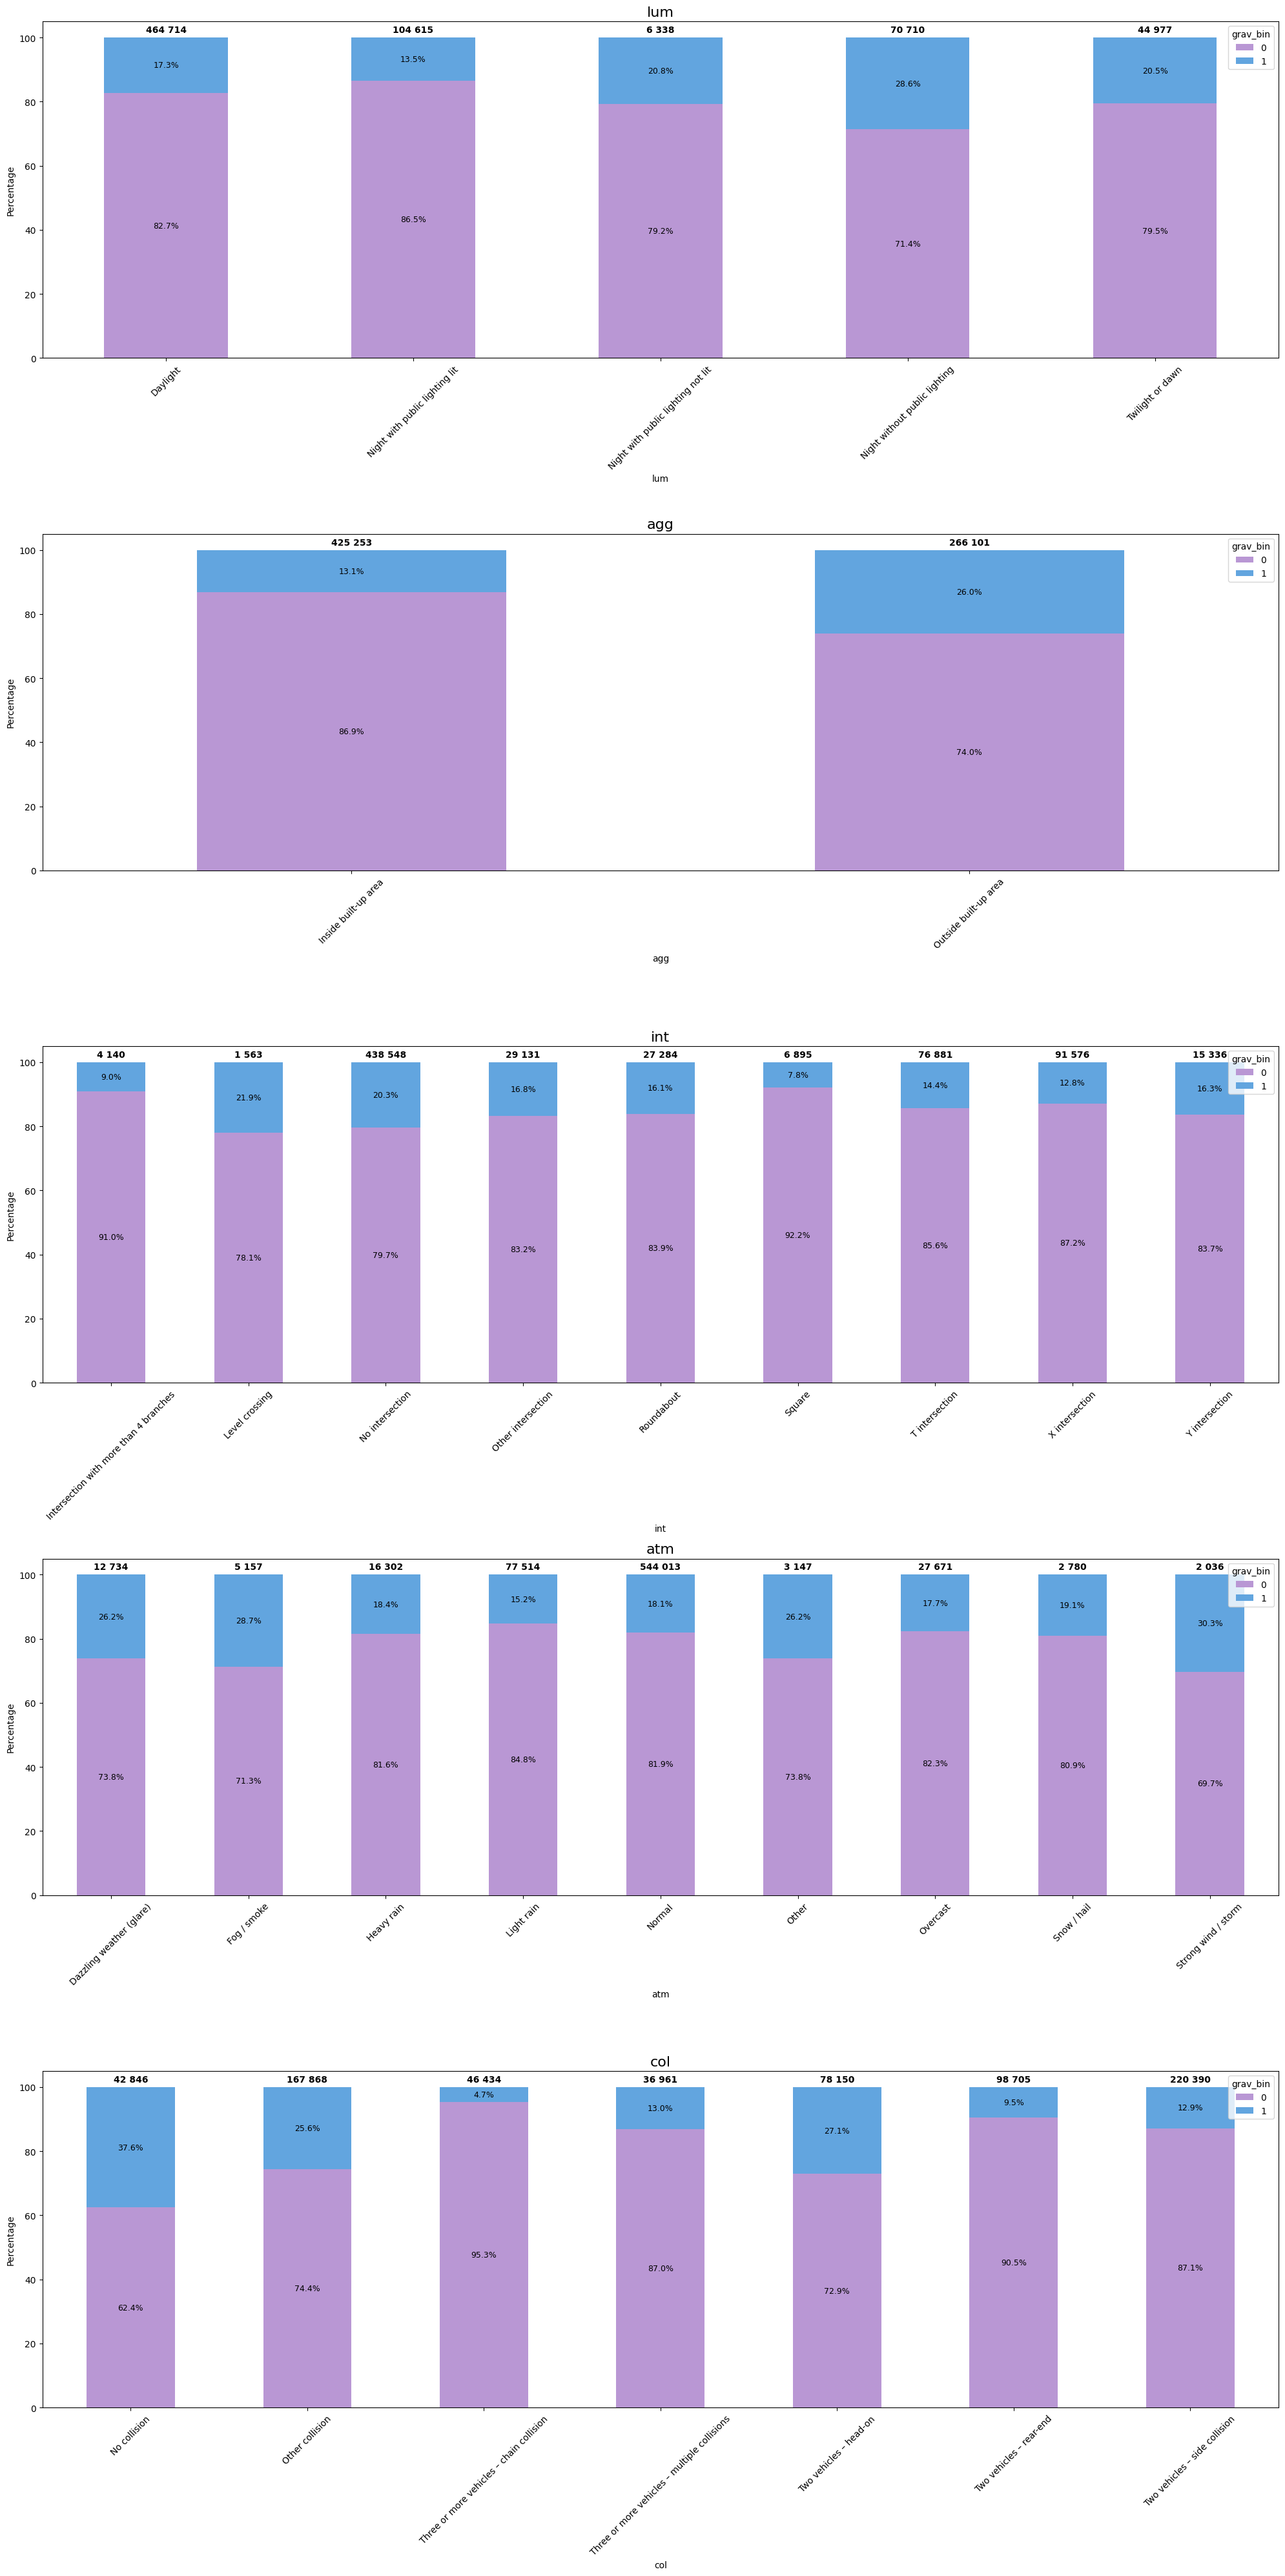

In [110]:
fig, ax = plt.subplots(len(categorical_features), 1, figsize=(20, 6*len(categorical_features) + 10))

df_caract_analyse = df_caract_analyse.reset_index(drop=True)

for i, feature in enumerate(categorical_features):
    ct = pandas.crosstab(
        df_caract_analyse[feature],
        df_caract_analyse[target],
        normalize="index"
    ) * 100

    counts = df_caract_analyse[feature].value_counts().sort_index()

    # Plot
    ct.plot(kind="bar", stacked=True, ax=ax[i], color=["#B997D4", "#62A5DF"])

    # Add % labels inside bars
    for j, category in enumerate(ct.index):
        cumulative = 0
        for k, col in enumerate(ct.columns):
            value = ct.loc[category, col]
            if value > 3:  # avoid clutter for tiny values
                ax[i].text(
                    j,
                    cumulative + value / 2,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="black"
                )
            cumulative += value

    # Add total count above bars
    for j, category in enumerate(ct.index):
        ax[i].text(
            j,
            101,  # slightly above 100%
            f"{counts[category]:,}".replace(",", " "),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax[i].set_title(feature, fontsize=16)
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].set_ylabel("Percentage")

plt.tight_layout()

In [ ]:
def latex_escape_category(x):
    """
    Convert category labels into LaTeX-safe strings.
    """
    x = str(x)

    # Replace comparison operators with LaTeX math symbols
    x = x.replace("<=", r"$\le$")
    x = x.replace(">=", r"$\ge$")
    x = x.replace("<", r"$<$")
    x = x.replace(">", r"$>$")

    # Escape LaTeX special characters
    x = x.replace("&", r"\&")
    x = x.replace("%", r"\%")
    x = x.replace("_", r"\_")
    x = x.replace("#", r"\#")

    return x

output_lines = []

all_features_to_analyse = categorical_features + binary_features
for feature in all_features_to_analyse:
    # Count per class
    counts = df_caract_analyse.groupby(feature)[target].value_counts().unstack(fill_value=0)
    
    # Proportions (in %)
    proportions = counts.div(counts.sum(axis=1), axis=0) * 100

    # Ensure column order (adapt if needed)
    # Assuming: 0 = not severe, 1 = severe
    for i, category in enumerate(counts.index):
        category_latex = latex_escape_category(category)
        count = counts.loc[category].sum()
        not_severe = proportions.loc[category].get(0, 0)
        severe = proportions.loc[category].get(1, 0)

        if i == 0:
            line = f"\\texttt{{{feature}}} & {category_latex} & {count:,} & {not_severe:.1f} & {severe:.1f} \\\\"
        else:
            line = f" & {category_latex} & {count:,} & {not_severe:.1f} & {severe:.1f} \\\\"

        # Replace commas for LaTeX formatting (French style spacing)
        line = line.replace(",", " ")

        output_lines.append(line)

    output_lines.append("\\hline")

# Print result
print("\n".join(output_lines))

\texttt{lum} & Daylight & 464 714 & 82.7 & 17.3 \\
 & Night with public lighting lit & 104 615 & 86.5 & 13.5 \\
 & Night with public lighting not lit & 6 338 & 79.2 & 20.8 \\
 & Night without public lighting & 70 710 & 71.4 & 28.6 \\
 & Twilight or dawn & 44 977 & 79.5 & 20.5 \\
\hline
\texttt{agg} & Inside built-up area & 425 253 & 86.9 & 13.1 \\
 & Outside built-up area & 266 101 & 74.0 & 26.0 \\
\hline
\texttt{int} & Intersection with more than 4 branches & 4 140 & 91.0 & 9.0 \\
 & Level crossing & 1 563 & 78.1 & 21.9 \\
 & No intersection & 438 548 & 79.7 & 20.3 \\
 & Other intersection & 29 131 & 83.2 & 16.8 \\
 & Roundabout & 27 284 & 83.9 & 16.1 \\
 & Square & 6 895 & 92.2 & 7.8 \\
 & T intersection & 76 881 & 85.6 & 14.4 \\
 & X intersection & 91 576 & 87.2 & 12.8 \\
 & Y intersection & 15 336 & 83.7 & 16.3 \\
\hline
\texttt{atm} & Dazzling weather (glare) & 12 734 & 73.8 & 26.2 \\
 & Fog / smoke & 5 157 & 71.3 & 28.7 \\
 & Heavy rain & 16 302 & 81.6 & 18.4 \\
 & Light rain & 7

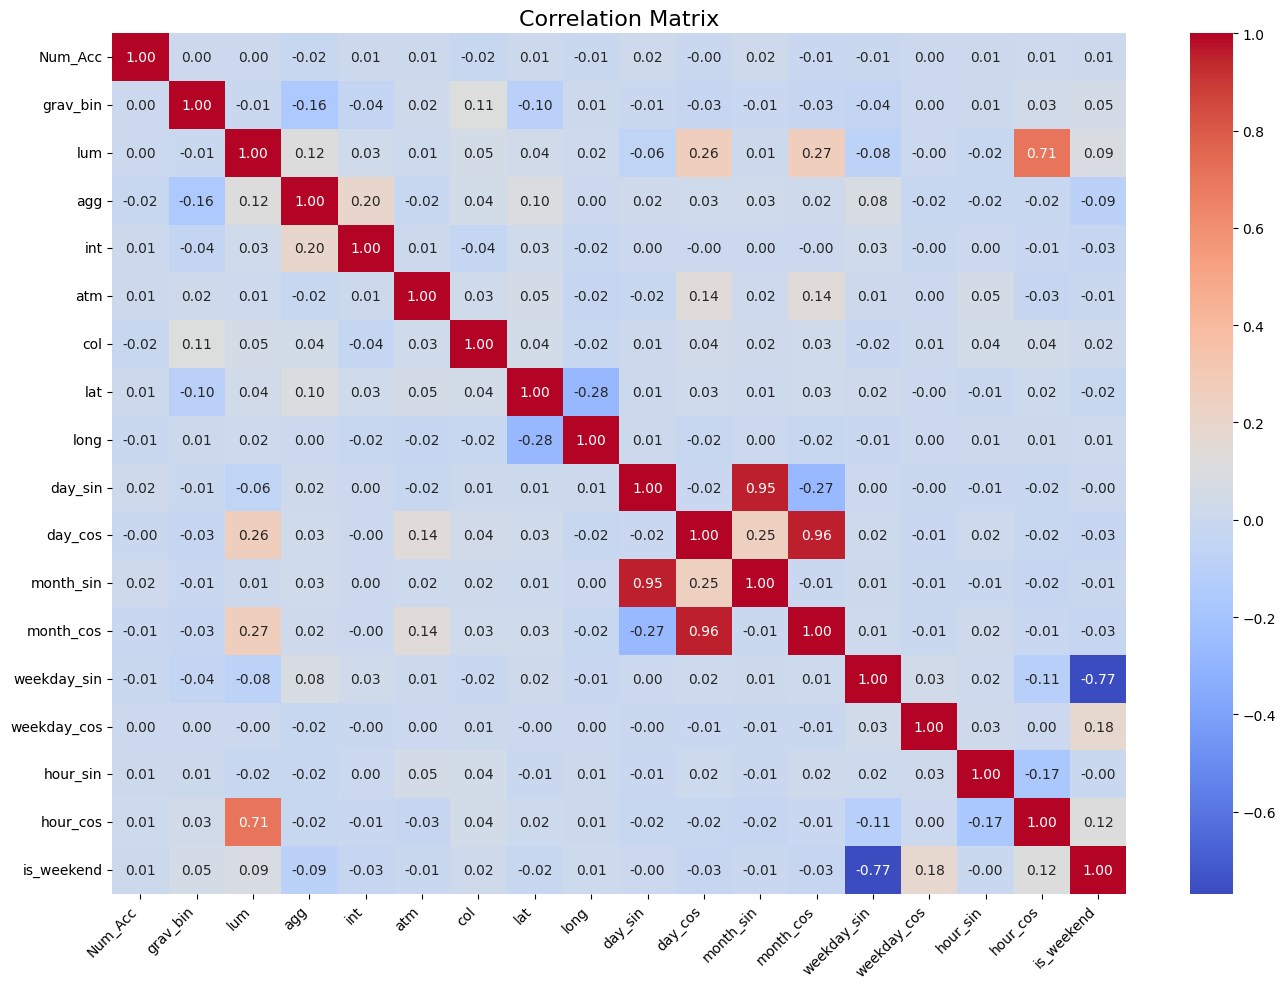

In [112]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    df_caract_with_target.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10}
)

plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [113]:
X = df_caract_with_target[categorical_features + numerical_features + binary_features]
y = df_caract_with_target[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [114]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("bin_cat", "passthrough", binary_features)
    ]
)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

pipelines_over = {}
pipelines_under = {}
pipelines_combine = {}
for name, model in models.items():
    pipelines_over[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("over", RandomOverSampler(random_state=42)),
        ("model", model)
    ])
    pipelines_under[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("under", RandomUnderSampler(random_state=42)),
        ("model", model)    
    ])

print(colored_text(BRIGHT_BLUE, "Evaluation des modèles avec over-sampling"))
for name, pipe in pipelines_over.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=5) # un label prédit pour chaque exemple de X_train
    
    precision = precision_score(y_train,y_pred)
    recall = recall_score(y_train, y_pred)
    f1 = f1_score(y_train,y_pred)
    accuracy = accuracy_score(y_train, y_pred)

    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)

    print(classification_report(y_train, y_pred))

print(colored_text(BRIGHT_BLUE, "Evaluation des modèles avec under-sampling"))
for name, pipe in pipelines_under.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=5) # un label prédit pour chaque exemple de X_train
    
    precision = precision_score(y_train,y_pred)
    recall = recall_score(y_train, y_pred)
    f1 = f1_score(y_train,y_pred)
    accuracy = accuracy_score(y_train, y_pred)

    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)

    print(classification_report(y_train, y_pred))

Evaluation des modèles avec over-sampling

 Logistic Regression
Precision: 0.3052659952689231
Recall: 0.65674492081267
F1: 0.4167975405233051
Accuracy: 0.667646628082946
              precision    recall  f1-score   support

           0       0.90      0.67      0.77    453067
           1       0.31      0.66      0.42    100016

    accuracy                           0.67    553083
   macro avg       0.60      0.66      0.59    553083
weighted avg       0.79      0.67      0.70    553083


 Decision Tree
Precision: 0.2883637701518496
Recall: 0.34480483122700367
F1: 0.31406870423663985
Accuracy: 0.7276430481500968
              precision    recall  f1-score   support

           0       0.85      0.81      0.83    453067
           1       0.29      0.34      0.31    100016

    accuracy                           0.73    553083
   macro avg       0.57      0.58      0.57    553083
weighted avg       0.75      0.73      0.74    553083


 Gradient Boosting
Precision: 0.3237114147655618

In [115]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size = .2)
print(colored_text(BRIGHT_BLUE, "Evaluation des modèles avec over-sampling"))
for name, pipe in pipelines_over.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val) # un label prédit pour chaque exemple de X_train
    
    precision, recall, f1, _ = precision_recall_fscore_support(y_val, y_pred, average="binary")
    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)

    print(classification_report(y_val, y_pred))

print(colored_text(BRIGHT_BLUE, "Evaluation des modèles avec under-sampling"))
for name, pipe in pipelines_under.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val) # un label prédit pour chaque exemple de X_train
    
    precision, recall, f1, _ = precision_recall_fscore_support(y_val, y_pred, average="binary")
    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)

    print(classification_report(y_val, y_pred)) 

Evaluation des modèles avec over-sampling

 Logistic Regression
Precision: 0.3059493403941233
Recall: 0.6535689258184002
F1: 0.4167903599074296
Accuracy: 0.6792344006234146
              precision    recall  f1-score   support

           0       0.90      0.67      0.77     90639
           1       0.31      0.65      0.42     19978

    accuracy                           0.67    110617
   macro avg       0.60      0.66      0.59    110617
weighted avg       0.79      0.67      0.71    110617


 Decision Tree
Precision: 0.59986842929641
Recall: 0.9585043547902693
F1: 0.7379190751445087
Accuracy: 0.6792344006234146
              precision    recall  f1-score   support

           0       0.99      0.86      0.92     90639
           1       0.60      0.96      0.74     19978

    accuracy                           0.88    110617
   macro avg       0.79      0.91      0.83    110617
weighted avg       0.92      0.88      0.89    110617


 Gradient Boosting
Precision: 0.32445679179653975

In [116]:
# Finally we are going to save the dataset cleaned
df_caract.to_csv("df_caract_clean.csv", index=False)